In [1]:
import sys
from pathlib import Path

path = str(Path.cwd().parent)
if path not in sys.path:
    sys.path.append(path)

from Src.Models.Network import Network
from Src.Models.Component import Port, Ground
from Src.Models.Circuit import Circuit


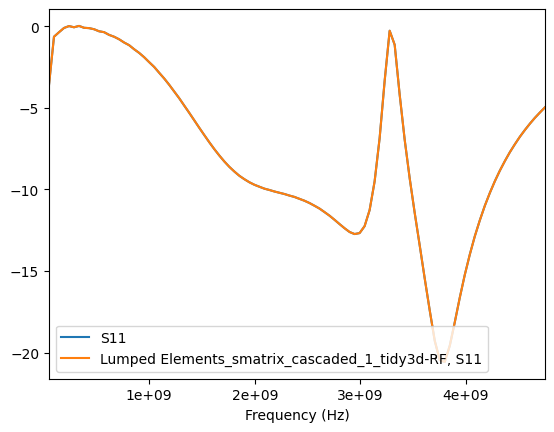

In [2]:
snp_gui = Network.from_touchstone("../Data/Touchstone/Lumped Elements_smatrix_cascaded_1_tidy3d-RF.s1p")
rf_snp = Network.from_touchstone("../Data/Touchstone/Lumped Elements_smatrix_tidy3d-RF.s4p")

port1 = Port(name='port1', frequency=rf_snp.frequency, z0=[50.0, 0.0])
gnd1 = Ground(name='gnd1', frequency=rf_snp.frequency, z0=[50.0, 0.0])
gnd2 = Ground(name='gnd2', frequency=rf_snp.frequency, z0=[50.0, 0.0])

networks = {
    'port1': port1,
    'gnd1': gnd1,
    'gnd2': gnd2,
    'rf_snp': rf_snp
}

connections = [
    [
        ('port1', 0),
        ('rf_snp', 0)
    ],
    [
        ('gnd1', 0),
        ('rf_snp', 1)
    ],
    [
        ('gnd2', 0),
        ('rf_snp', 2)
    ],
]

rf_circuit = Circuit(networks=networks, connections=connections)
skrf_circuit = rf_circuit.to_circuit()
skrf_circuit.network.plot_s_db()
snp_gui.to_network().plot_s_db()